# Phase 2: Unsupervised Learning for Initial Detection (Anomaly-Based IDS)
# Task 2.1: Packet-Level Anomaly Detection
# Autoencoder

Build an unsupervised model that separates benign from non-benign packets.

## Setup, load metadata and sampled packet dataset

In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME

with open(META_PATH, "r") as f:
    metadata = json.load(f)

DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
y_true = df[BINARY_COL].map({"benign": 0, "attack": 1}).to_numpy()

print("Dataset shape:", df.shape)
print("\nBinary class counts:")
print(df[BINARY_COL].value_counts())
print("\nTraffic type counts:")
print(df[ATTACK_COL].value_counts())

Dataset shape: (205041, 138)

Binary class counts:
binary_label
benign    200000
attack      5041
Name: count, dtype: int64

Traffic type counts:
attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## Data preprocessing

### Autoencoder feature selection

The autoencoder uses numeric packet behavior, protocol, timing, size, and short-term traffic statistics. Raw IP addresses, MAC addresses, host names, URIs, and user-agent strings are excluded because they are identifiers rather than stable behavior features. A small set of 1, 5, and 30-window statistics is kept, then highly correlated columns are removed using the training set only.

In [2]:
# Basic packet behavior features
base_features = [
    "time_since_previously_displayed_frame",
    "port_class_dst",
    "l4_tcp",
    "l4_udp",
    "ttl",
    "eth_size",
    "tcp_window_size",
    "payload_entropy",
    "payload_length",
    "jitter",
    "dns_len_qry",
    "dns_interval",
    "dns_len_ans",
    "http_content_len",
    "http_response_code",
    "handshake_cipher_suites_length",
    "handshake_extensions_length",
    "handshake_sig_hash_alg_len",
    "icmp_data_size",
    "l3_ip_dst_count",
    "average_p",
    "var_p",
    "iqr_p"
]

# Keep useful short-term and longer-term traffic statistics
rolling_features = []

for group in ["stream", "src_ip", "channel"]:
    rolling_features += [f"{group}_{window}_count" for window in [1, 5, 30]]
    rolling_features += [f"{group}_{window}_{stat}" for window in [5, 30] for stat in ["mean", "var"]]

rolling_features += [
    "stream_jitter_5_mean",
    "stream_jitter_5_var",
    "stream_jitter_30_mean",
    "stream_jitter_30_var"
]

requested_features = base_features + rolling_features
missing_features = [col for col in requested_features if col not in df.columns]
feature_cols = [col for col in requested_features if col in df.columns]
X_raw = df[feature_cols].apply(pd.to_numeric, errors="coerce").copy()

print("Initial selected features:", X_raw.shape[1])
print("Missing requested features:", missing_features)

Initial selected features: 48
Missing requested features: []


### Autoencoder feature engineering

The added features describe protocol usage, payload presence, port behavior, and sudden traffic bursts. These are more useful than raw port numbers and help the autoencoder learn normal packet relationships without using labels.

In [3]:
src_port = pd.to_numeric(df["src_port"], errors="coerce").fillna(-1)
dst_port = pd.to_numeric(df["dst_port"], errors="coerce").fillna(-1)
packet_size = pd.to_numeric(df["eth_size"], errors="coerce").replace(0, np.nan)
payload_size = pd.to_numeric(df["payload_length"], errors="coerce").fillna(0)
dns_query = pd.to_numeric(df["dns_len_qry"], errors="coerce").fillna(0)
dns_answer = pd.to_numeric(df["dns_len_ans"], errors="coerce").fillna(0)
http_length = pd.to_numeric(df["http_content_len"], errors="coerce").fillna(0)
http_code = pd.to_numeric(df["http_response_code"], errors="coerce").fillna(0)
tls_length = pd.to_numeric(df["handshake_extensions_length"], errors="coerce").fillna(0)
icmp_size = pd.to_numeric(df["icmp_data_size"], errors="coerce").fillna(-1)

X_raw["payload_ratio"] = (payload_size / packet_size).clip(0, 1).fillna(0)
X_raw["has_payload"] = (payload_size > 0).astype(int)
X_raw["uses_dns_port"] = ((src_port == 53) | (dst_port == 53)).astype(int)
X_raw["has_dns_data"] = ((dns_query > 0) | (dns_answer > 0)).astype(int)
X_raw["uses_http_port"] = ((src_port == 80) | (dst_port == 80)).astype(int)
X_raw["uses_https_port"] = ((src_port == 443) | (dst_port == 443)).astype(int)
X_raw["has_http_data"] = ((http_length > 0) | (http_code > 0)).astype(int)
X_raw["has_tls_handshake"] = (tls_length > 0).astype(int)
X_raw["is_icmp"] = (icmp_size >= 0).astype(int)
X_raw["src_port_ephemeral"] = (src_port >= 49152).astype(int)
X_raw["dst_port_ephemeral"] = (dst_port >= 49152).astype(int)

def burst_ratio(short_col, long_col):
    short_count = pd.to_numeric(df[short_col], errors="coerce").fillna(0)
    long_count = pd.to_numeric(df[long_col], errors="coerce").fillna(0)
    recent_rate = short_count / 5
    previous_rate = (long_count - short_count).clip(lower=0) / 25
    return (recent_rate + 1) / (previous_rate + 1)

for group in ["stream", "src_ip", "channel"]:
    X_raw[f"{group}_burst_ratio"] = burst_ratio(f"{group}_5_count", f"{group}_30_count")

print("Features after engineering:", X_raw.shape[1])
X_raw.head()

Features after engineering: 62


,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,payload_length,jitter,...,uses_http_port,uses_https_port,has_http_data,has_tls_handshake,is_icmp,src_port_ephemeral,dst_port_ephemeral,stream_burst_ratio,src_ip_burst_ratio,channel_burst_ratio
0,0.000185,1,1,0,64,60,0,0.000000,0,0.000185,...,0,1,0,0,0,0,0,3.800000,1.179039,3.800000
1,0.000290,3,1,0,49,66,65024,0.000000,0,0.000290,...,0,1,0,0,0,0,1,2.800000,1.085714,1.051051
2,0.003855,1,1,0,64,74,14600,0.000000,0,947.623914,...,0,1,0,0,0,1,0,1.200000,1.081081,1.072508
3,0.003104,3,0,1,64,60,0,3.201876,16,0.005255,...,0,0,0,0,0,1,1,2.777778,1.371681,2.826087
4,0.000001,3,1,0,231,66,4415,0.000000,0,0.000001,...,0,1,0,0,0,0,1,1.429706,1.451327,1.429140


### Basic preprocessing

The data is divided into 60% training, 20% validation, and 20% test sets using the same split style as the K-means and Isolation Forest notebooks. Preprocessing is learned from the training set only. Missing rolling variance or jitter values are set to zero because they usually mean that too few earlier packets were available. Other missing values are median-imputed, skewed non-negative features are log-transformed, highly correlated features are removed, and the remaining inputs are standardized for neural-network training. Standardized values are clipped to the range -10 to 10 so a few extreme packets do not dominate the reconstruction loss.

Labels are stored only for validation and final evaluation. They are not passed to the autoencoder or its optimizer during fitting.

In [4]:
# Create 60% training, 20% validation and 20% test sets
all_idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(all_idx, test_size=0.40, random_state=1, stratify=df[ATTACK_COL])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=1, stratify=df.iloc[temp_idx][ATTACK_COL])

# Clean values before learning preprocessing information
X_clean = X_raw.replace([np.inf, -np.inf], np.nan).copy()
zero_fill_cols = [col for col in X_clean.columns if col.endswith("_var") or "jitter" in col]
X_clean[zero_fill_cols] = X_clean[zero_fill_cols].fillna(0)

X_train_df = X_clean.iloc[train_idx].copy()
X_val_df = X_clean.iloc[val_idx].copy()
X_test_df = X_clean.iloc[test_idx].copy()

# Remove unusable columns using training data only
drop_cols = [col for col in X_train_df.columns if X_train_df[col].isna().all() or X_train_df[col].nunique(dropna=True) <= 1]
X_train_df = X_train_df.drop(columns=drop_cols)
X_val_df = X_val_df.drop(columns=drop_cols)
X_test_df = X_test_df.drop(columns=drop_cols)

# Reduce extreme skew without changing binary indicators
log_cols = []
for col in X_train_df.columns:
    values = X_train_df[col].dropna()
    if len(values) > 0 and values.min() >= 0 and values.nunique() > 2 and abs(values.skew()) > 2:
        log_cols.append(col)

for split in [X_train_df, X_val_df, X_test_df]:
    split[log_cols] = np.log1p(split[log_cols].clip(lower=0))

# Remove nearly duplicate features using training correlations only
CORRELATED_FEATURE_THRESHOLD = 0.98
correlation = X_train_df.corr(numeric_only=True).abs()
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
correlated_cols = [col for col in upper_triangle.columns if (upper_triangle[col] > CORRELATED_FEATURE_THRESHOLD).any()]

X_train_df = X_train_df.drop(columns=correlated_cols)
X_val_df = X_val_df.drop(columns=correlated_cols)
X_test_df = X_test_df.drop(columns=correlated_cols)

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

X_train = preprocess.fit_transform(X_train_df).astype(np.float32)
X_val = preprocess.transform(X_val_df).astype(np.float32)
X_test = preprocess.transform(X_test_df).astype(np.float32)

X_train = np.clip(X_train, -10, 10)
X_val = np.clip(X_val, -10, 10)
X_test = np.clip(X_test, -10, 10)
processed_feature_names = preprocess.named_steps["imputer"].get_feature_names_out(X_train_df.columns)

y_train = y_true[train_idx]
y_val = y_true[val_idx]
y_test = y_true[test_idx]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("\nPreprocessing summary:")
print("Removed unusable features:", len(drop_cols))
print("Removed correlated features:", len(correlated_cols))
print("Log-transformed features:", len(log_cols))
print("Final model inputs:", len(processed_feature_names))
print("All values finite:", np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all())
print("\nAttack counts:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

Training shape: (123024, 61)
Validation shape: (41008, 61)
Test shape: (41009, 61)

Preprocessing summary:
Removed unusable features: 0
Removed correlated features: 6
Log-transformed features: 45
Final model inputs: 61
All values finite: True

Attack counts:
Train: 3024
Validation: 1008
Test: 1009


## Autoencoder model

The model is a small denoising autoencoder. During training, Gaussian noise is added to each input batch, while the clean batch remains the reconstruction target. This discourages the network from learning a simple identity mapping. The encoder compresses the packet features into a low-dimensional bottleneck and the decoder reconstructs the original standardized features.

Packet labels are not used by the model, loss function, optimizer, or early-stopping rule.

In [5]:
torch.set_num_threads(min(4, os.cpu_count() or 1))

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

RANDOM_STATE = 1
BATCH_SIZE = 1024 if len(X_train) >= 1024 else 128


def set_seed(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class PacketAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8, dropout=0.10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


print("Device:", DEVICE)
print("Input features:", X_train.shape[1])
print("Training batch size:", BATCH_SIZE)

Device: mps
Input features: 61
Training batch size: 1024


### Training and reconstruction-error functions

Early stopping uses validation reconstruction loss only. It does not use the validation labels. The anomaly score for one packet is its mean squared reconstruction error across all processed input features.

In [6]:
def make_loader(X, batch_size, shuffle=False):
    data = TensorDataset(torch.from_numpy(X))
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=DEVICE.type == "cuda")


def train_autoencoder(X_train, X_val, bottleneck_dim, dropout=0.10, noise_std=0.05, learning_rate=1e-3, weight_decay=1e-5, max_epochs=25, patience=4):
    set_seed()
    model = PacketAutoencoder(X_train.shape[1], bottleneck_dim, dropout).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    train_loader = make_loader(X_train, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, BATCH_SIZE)
    history, best_loss, best_state, wait = [], np.inf, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            noisy_batch = batch + noise_std * torch.randn_like(batch)
            optimizer.zero_grad()
            loss = criterion(model(noisy_batch), batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(batch)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                val_loss += criterion(model(batch), batch).item() * len(batch)

        train_loss /= len(X_train)
        val_loss /= len(X_val)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_loss - 1e-5:
            best_loss = val_loss
            best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


@torch.no_grad()
def reconstruction_errors(model, X, batch_size=4096):
    model.eval()
    errors = []
    for (batch,) in make_loader(X, batch_size):
        batch = batch.to(DEVICE)
        reconstruction = model(batch)
        errors.append(torch.mean((reconstruction - batch) ** 2, dim=1).cpu().numpy())
    return np.concatenate(errors)

## Tuning

### Tune the bottleneck size

A bottleneck that is too small may lose useful normal-traffic structure, while a large bottleneck may reconstruct attacks too easily. The candidate models below are trained without labels. After training, validation labels are used only to compare the anomaly-score ranking through PR-AUC and ROC-AUC. PR-AUC is the main selection metric because the attack class is highly imbalanced.

In [7]:
bottleneck_values = [4, 6, 8, 10, 12, 14, 16, 20, 30, 32]
tuning_rows = []

for bottleneck_dim in bottleneck_values:
    start_time = time.time()
    model, history = train_autoencoder(X_train, X_val, bottleneck_dim, max_epochs=20)
    val_scores = reconstruction_errors(model, X_val)
    tuning_rows.append({
        "bottleneck_dim": bottleneck_dim,
        "epochs": len(history),
        "val_loss": history["val_loss"].min(),
        "val_pr_auc": average_precision_score(y_val, val_scores),
        "val_roc_auc": roc_auc_score(y_val, val_scores),
        "train_time_sec": time.time() - start_time
    })
    print(f"Bottleneck {bottleneck_dim}: PR-AUC={tuning_rows[-1]['val_pr_auc']:.4f}, epochs={len(history)}")

autoencoder_tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
display(autoencoder_tuning_df.round(4))

Bottleneck 4: PR-AUC=0.1662, epochs=20
Bottleneck 6: PR-AUC=0.1820, epochs=20
Bottleneck 8: PR-AUC=0.1936, epochs=20
Bottleneck 10: PR-AUC=0.1926, epochs=20
Bottleneck 12: PR-AUC=0.1801, epochs=20
Bottleneck 14: PR-AUC=0.1822, epochs=20
Bottleneck 16: PR-AUC=0.1727, epochs=20
Bottleneck 20: PR-AUC=0.2050, epochs=20
Bottleneck 30: PR-AUC=0.1670, epochs=20
Bottleneck 50: PR-AUC=0.2198, epochs=20


,bottleneck_dim,epochs,val_loss,val_pr_auc,val_roc_auc,train_time_sec
0,50,20,0.0611,0.2198,0.8900,18.1421
1,20,20,0.0650,0.2050,0.8750,18.6910
2,8,20,0.0836,0.1936,0.8643,18.2094
3,10,20,0.0742,0.1926,0.8720,20.8406
4,14,20,0.0774,0.1822,0.8694,19.4554
5,6,20,0.0962,0.1820,0.8704,20.1069
6,12,20,0.0705,0.1801,0.8684,21.9469
7,16,20,0.0684,0.1727,0.8620,18.5985
8,30,20,0.0617,0.1670,0.8720,18.0817
9,4,20,0.1208,0.1662,0.8588,38.9233


### Select the best bottleneck

The selected bottleneck is the candidate with the highest validation PR-AUC. The test set is not used for model selection.

In [8]:
best_row = autoencoder_tuning_df.iloc[0]
BEST_BOTTLENECK = int(best_row["bottleneck_dim"])

print("Selected bottleneck size:", BEST_BOTTLENECK)
print("Validation PR-AUC:", round(best_row["val_pr_auc"], 4))
print("Validation ROC-AUC:", round(best_row["val_roc_auc"], 4))

Selected bottleneck size: 50
Validation PR-AUC: 0.2198
Validation ROC-AUC: 0.89


## Training model

### Train the final denoising autoencoder


Training epochs: 30
Best validation loss: 0.052241
Training time (seconds): 30.68


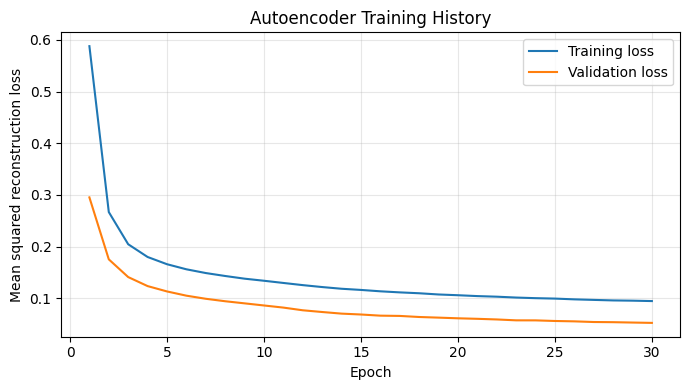

In [9]:
start_train = time.time()
autoencoder, training_history = train_autoencoder(X_train, X_val, BEST_BOTTLENECK, max_epochs=30, patience=5)
train_time = time.time() - start_train

print("Training epochs:", len(training_history))
print("Best validation loss:", round(training_history["val_loss"].min(), 6))
print("Training time (seconds):", round(train_time, 2))

plt.figure(figsize=(7, 4))
plt.plot(training_history["epoch"], training_history["train_loss"], label="Training loss")
plt.plot(training_history["epoch"], training_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared reconstruction loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Generate validation and test anomaly scores


In [10]:
start_score = time.time()
train_scores = reconstruction_errors(autoencoder, X_train)
val_scores = reconstruction_errors(autoencoder, X_val)
test_scores = reconstruction_errors(autoencoder, X_test)
score_time = time.time() - start_score

score_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "mean_score": [train_scores.mean(), val_scores.mean(), test_scores.mean()],
    "median_score": [np.median(train_scores), np.median(val_scores), np.median(test_scores)],
    "max_score": [train_scores.max(), val_scores.max(), test_scores.max()]
})

print("Scoring time (seconds):", round(score_time, 2))
display(score_summary.round(6))

Scoring time (seconds): 1.11


,split,mean_score,median_score,max_score
0,Train,0.052336,0.036927,1.689281
1,Validation,0.052241,0.037036,1.215376
2,Test,0.052010,0.037084,1.258942
